# 第14回：Session 1-13 確認レポート課題（宿題）

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Nakaura-T/DS_Seminar1_Public/blob/main/notebooks/session14_report_sessions01_13.ipynb)

**DSゼミナールⅠ（2026年度）**  
熊本大学 情報融合学環　256x1130　嶋田悠

このNotebookは、Session 1-13の内容を理解できているかを確認するための宿題レポートです。

まとめ資料を見ながら、自分でコードを実行し、結果を文章で説明してください。

---

## 📋 課題の目的

1. データの読み込み、確認、前処理ができる
2. 記述統計と可視化でデータの特徴を説明できる
3. 分類モデルを作り、評価指標を解釈できる
4. 回帰モデルを作り、予測誤差を解釈できる
5. PCAと特徴量重要度を使って特徴量を説明できる
6. 分析結果をIMRADに近い形でまとめられる

---

## 提出物

このNotebookを完成させ、PDFまたはHTMLに変換して提出してください。

- 学籍番号：ここに記入
- 氏名：ここに記入
- 提出期限・提出先：授業内の案内に従ってください

提出前に、上から順番にすべてのセルを実行し、エラーが出ないことを確認してください。

---

## 使用データ

今回は、授業で使用した `winequality.csv` を使います。

このデータには、ワインの化学的特徴量、品質スコア、赤ワイン/白ワインの種類が含まれています。


In [1]:
import sys
import subprocess

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.decomposition import PCA

try:
    import japanize_matplotlib
except ImportError:
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "japanize-matplotlib",
        "-q",
    ])
    import japanize_matplotlib

sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "IPAexGothic"
plt.rcParams["axes.unicode_minus"] = False


In [2]:
wine_url = "https://raw.githubusercontent.com/Nakaura-T/DS_Seminar1_Public/main/notebooks/data/winequality.csv"
df = pd.read_csv(wine_url)

df.head()


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,ph,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


---

## 1. Introduction：分析目的を書く

この課題では、次の2つの問いに答えてください。

1. ワインの特徴量から、赤ワインと白ワインを分類できるか
2. ワインの特徴量から、品質スコアを予測できるか

### 記入欄

以下に、今回の分析目的を自分の言葉で書いてください。

```text
ここに記入：
ワインの選別を簡単にし、出荷にかかる人件費を減らすため
```

---

## 2. データの基本確認

### 2-1. 行数・列数を確認する


In [4]:
print(df.shape)

(6497, 13)


### 2-2. 列名とデータ型を確認する


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed_acidity         6497 non-null   float64
 1   volatile_acidity      6497 non-null   float64
 2   citric_acid           6497 non-null   float64
 3   residual_sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free_sulfur_dioxide   6497 non-null   float64
 6   total_sulfur_dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   ph                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  type                  6497 non-null   object 
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB


### 2-3. 欠損値を確認する


In [6]:
df.isnull().sum()

,0
fixed_acidity,0
volatile_acidity,0
citric_acid,0
residual_sugar,0
chlorides,0
free_sulfur_dioxide,0
total_sulfur_dioxide,0
density,0
ph,0
sulphates,0


### 2-4. 要約統計量を確認する


In [7]:
df.describe()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,ph,sulphates,alcohol,quality
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,4.310605
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,1.151220
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,1.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,3.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,4.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,5.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,8.000000


### 記入欄

データの行数、列数、欠損値の有無、気づいた特徴を2-4文で書いてください。

```text
ここに記入：
このデータセットには6497行と13列が含まれている。
全ての列に欠損値はなく、データは完全に揃っている。  
特徴量には浮動小数点型の数値が多く、`quality`は整数型、`type`はオブジェクト型である。  
また、`quality`のスコアは1から8の範囲に分布しており、その平均値は4.31程度だ。

```

---

## 3. 記述統計と可視化

### 3-1. ワインの種類の件数を確認する


In [9]:
df["type"].value_counts()

,count
type,
white,4898
red,1599


### 3-2. 品質スコアの分布を可視化する


<Axes: xlabel='quality', ylabel='Count'>

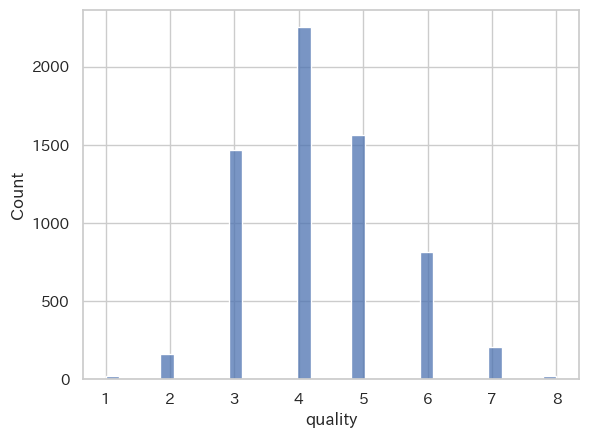

In [10]:
sns.histplot(x='quality', data=df)

### 3-3. 赤ワイン/白ワイン別に品質スコアを比較する


<Axes: xlabel='type', ylabel='quality'>

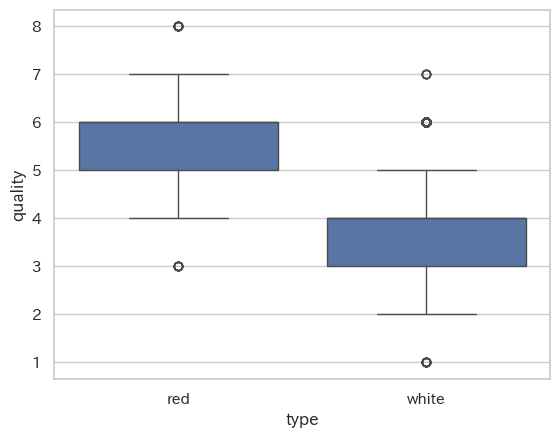

In [11]:
sns.boxplot(x='type', y='quality', data=df)

### 3-4. 特徴量同士の関係を可視化する


<Axes: xlabel='alcohol', ylabel='density'>

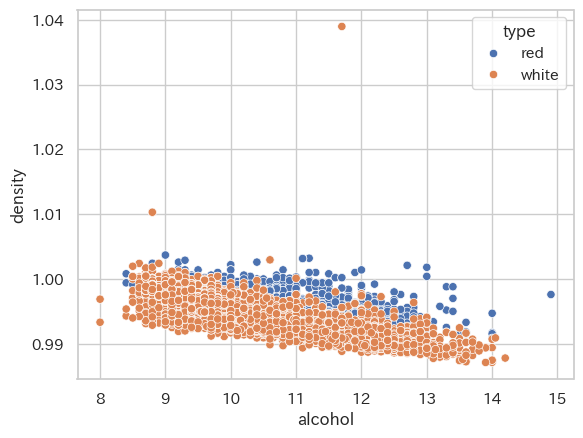

In [12]:
sns.scatterplot(x='alcohol', y='density', hue='type', data=df)

### 記入欄

作成した図から読み取れることを3-5文で書いてください。

```text
ここに記入：
アルコール度数と密度には負の相関関係が見られ、アルコール度数が高くなるほど密度が低くなる傾向がある。
特に、白ワインは広範囲に分布していますが、赤ワインはアルコール度数が比較的低く、密度が高い領域に集中している傾向がある。
このことから、アルコール度数と密度の組み合わせはワインのタイプを区別する上で有効な特徴量であることが示唆される。

```

---

## 4. 分類課題：赤ワイン/白ワインを分類する

ここでは、`type` を目的変数として、赤ワインか白ワインかを分類します。

### 4-1. 説明変数と目的変数を作る


In [14]:
feature_cols = [
    "fixed_acidity",
    "volatile_acidity",
    "citric_acid",
    "residual_sugar",
    "chlorides",
    "free_sulfur_dioxide",
    "total_sulfur_dioxide",
    "density",
    "ph",
    "sulphates",
    "alcohol",
]

# ヒント：
# X_cls = df[feature_cols]
# y_cls = (df["type"] == "red").astype(int)


### 4-2. 訓練データとテストデータに分割する


In [15]:
X_cls = df[feature_cols]
y_cls = (df["type"] == "red").astype(int)
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls)

### 4-3. Logistic回帰モデルを作る


In [16]:
logreg_model = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(max_iter=1000, random_state=42))
])

### 4-4. 学習と予測を行う


In [17]:
logreg_model.fit(X_train_cls, y_train_cls)
y_pred_logreg = logreg_model.predict(X_test_cls)
y_prob_logreg = logreg_model.predict_proba(X_test_cls)[:, 1]

### 4-5. 評価指標を計算する


In [18]:
print(f"Accuracy: {accuracy_score(y_test_cls, y_pred_logreg):.4f}")
print(f"Precision: {precision_score(y_test_cls, y_pred_logreg):.4f}")
print(f"Recall: {recall_score(y_test_cls, y_pred_logreg):.4f}")
print(f"F1-score: {f1_score(y_test_cls, y_pred_logreg):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test_cls, y_prob_logreg):.4f}")
print("\nClassification Report:\n")
print(classification_report(y_test_cls, y_pred_logreg))

Accuracy: 0.9969
Precision: 0.9938
Recall: 0.9938
F1-score: 0.9938
ROC-AUC: 0.9949

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       980
           1       0.99      0.99      0.99       320

    accuracy                           1.00      1300
   macro avg       1.00      1.00      1.00      1300
weighted avg       1.00      1.00      1.00      1300



### 4-6. 混同行列を表示する


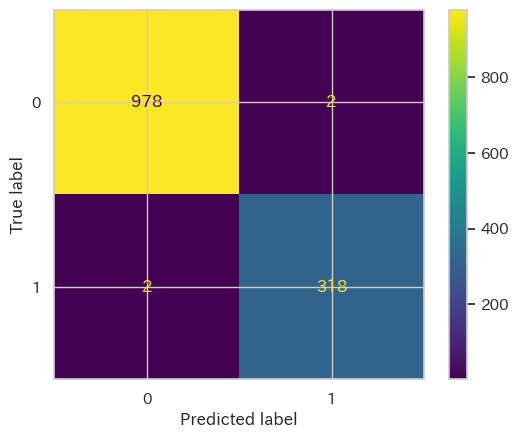

In [19]:
ConfusionMatrixDisplay.from_predictions(y_test_cls, y_pred_logreg)

### 記入欄

分類モデルの結果を説明してください。Accuracy、Precision、Recall、F1-score、ROC-AUCのうち、少なくとも3つに触れてください。

```text
ここに記入：
ロジスティック回帰モデルは非常に高い分類性能を示してる。
Accuracyは0.9969と、モデルがほとんどのワインのタイプを正確に分類できた。
PrecisionとRecallは両方とも0.9938であり、赤ワインと予測されたもののほとんどが実際に赤ワインであり（Precision）、実際の赤ワインのほとんどをモデルが正しく検出できた（Recall）ことを示してる。
F1-scoreも0.9938と高く、PrecisionとRecallのバランスが良いことを表してる。
ROC-AUCも0.9949と1に非常に近く、モデルが高い識別能力を持っていることを示している。


```

---

## 5. 分類モデルの比較

Logistic回帰とRandom Forest分類を比較してください。

### 5-1. Random Forest分類モデルを作る


In [20]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_cls, y_train_cls)
y_pred_rf = rf_model.predict(X_test_cls)
y_prob_rf = rf_model.predict_proba(X_test_cls)[:, 1]

### 5-2. 2つのモデルの性能を表にまとめる


In [21]:
logreg_metrics = {
    'model': 'Logistic Regression',
    'accuracy': accuracy_score(y_test_cls, y_pred_logreg),
    'precision': precision_score(y_test_cls, y_pred_logreg),
    'recall': recall_score(y_test_cls, y_pred_logreg),
    'f1': f1_score(y_test_cls, y_pred_logreg),
    'roc_auc': roc_auc_score(y_test_cls, y_prob_logreg)
}

rf_metrics = {
    'model': 'Random Forest',
    'accuracy': accuracy_score(y_test_cls, y_pred_rf),
    'precision': precision_score(y_test_cls, y_pred_rf),
    'recall': recall_score(y_test_cls, y_pred_rf),
    'f1': f1_score(y_test_cls, y_pred_rf),
    'roc_auc': roc_auc_score(y_test_cls, y_prob_rf)
}

metrics_df = pd.DataFrame([logreg_metrics, rf_metrics])
print(metrics_df)

                 model  accuracy  precision   recall        f1   roc_auc
0  Logistic Regression  0.996923   0.993750  0.99375  0.993750  0.994888
1        Random Forest  0.997692   0.996865  0.99375  0.995305  0.999984


### 5-3. 性能比較を可視化する


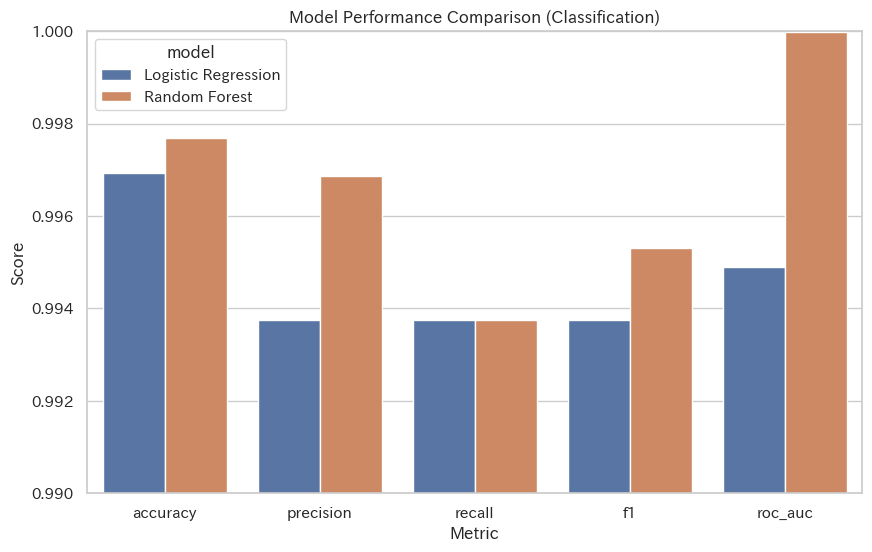

In [22]:
metrics_long = metrics_df.melt(id_vars='model', var_name='metric', value_name='score')

plt.figure(figsize=(10, 6))
sns.barplot(x='metric', y='score', hue='model', data=metrics_long)
plt.title('Model Performance Comparison (Classification)')
plt.ylim(0.99, 1.0)
plt.ylabel('Score')
plt.xlabel('Metric')
plt.show()

### 記入欄

どちらのモデルを採用したいか、理由を2-4文で書いてください。

```text
ここに記入：
単純に性能が高いのでrandom　modelを採用したい。
正確性が大事なのでなおさら採用したい。

```

---

## 6. 回帰課題：品質スコアを予測する

ここでは、`quality` を目的変数として、品質スコアを予測します。

### 6-1. 説明変数と目的変数を作る


In [23]:
X_reg = df[feature_cols]
y_reg = df["quality"]

### 6-2. 訓練データとテストデータに分割する


In [24]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

### 6-3. 線形回帰モデルを作る


In [25]:
linear_model = Pipeline([
    ('scaler', StandardScaler()),
    ('linear', LinearRegression())
])

linear_model.fit(X_train_reg, y_train_reg)
y_pred_linear = linear_model.predict(X_test_reg)

### 6-4. Random Forest回帰モデルを作る


In [26]:
rf_reg_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg_model.fit(X_train_reg, y_train_reg)
y_pred_rf_reg = rf_reg_model.predict(X_test_reg)

### 6-5. 回帰評価指標を計算する


In [27]:
linear_reg_metrics = {
    'model': 'Linear Regression',
    'MAE': mean_absolute_error(y_test_reg, y_pred_linear),
    'RMSE': np.sqrt(mean_squared_error(y_test_reg, y_pred_linear)),
    'R2': r2_score(y_test_reg, y_pred_linear)
}

rf_reg_metrics = {
    'model': 'Random Forest Regression',
    'MAE': mean_absolute_error(y_test_reg, y_pred_rf_reg),
    'RMSE': np.sqrt(mean_squared_error(y_test_reg, y_pred_rf_reg)),
    'R2': r2_score(y_test_reg, y_pred_rf_reg)
}

reg_metrics_df = pd.DataFrame([linear_reg_metrics, rf_reg_metrics])
print(reg_metrics_df)

                      model       MAE      RMSE        R2
0         Linear Regression  0.647198  0.841706  0.446826
1  Random Forest Regression  0.454140  0.636470  0.683702


### 6-6. 実測値 vs 予測値の散布図を作る


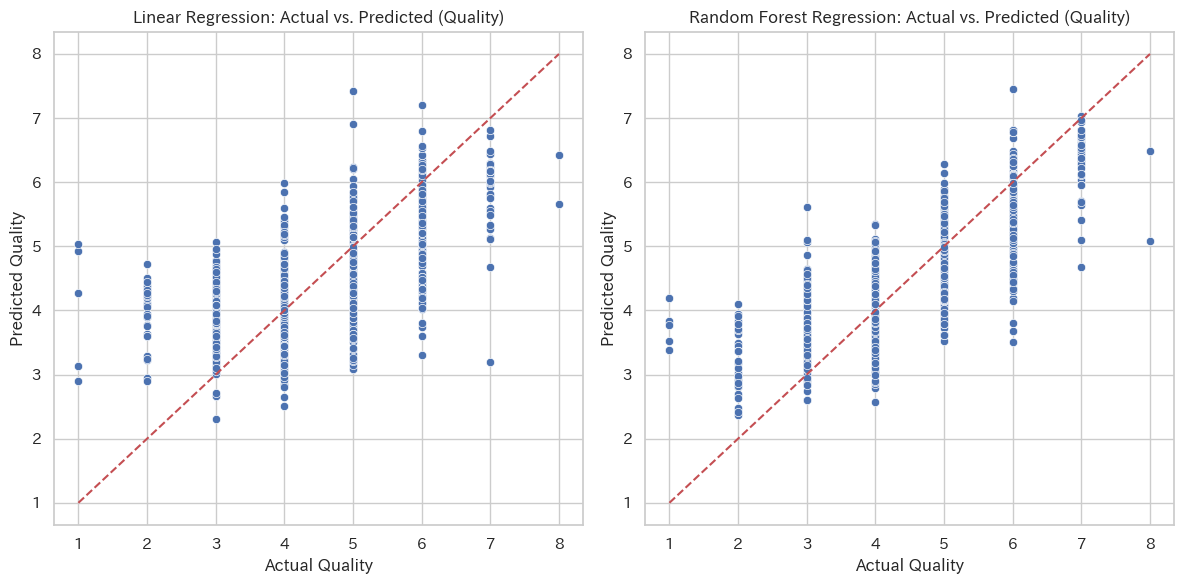

In [28]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test_reg, y=y_pred_linear)
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--')
plt.title('Linear Regression: Actual vs. Predicted (Quality)')
plt.xlabel('Actual Quality')
plt.ylabel('Predicted Quality')

plt.subplot(1, 2, 2)
sns.scatterplot(x=y_test_reg, y=y_pred_rf_reg)
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--')
plt.title('Random Forest Regression: Actual vs. Predicted (Quality)')
plt.xlabel('Actual Quality')
plt.ylabel('Predicted Quality')

plt.tight_layout()
plt.show()

### 記入欄

回帰モデルの結果を説明してください。MAE、RMSE、R²の意味にも触れてください。

```text
ここに記入：
ランダムフォレスト回帰モデルは、線形回帰モデルと比較して、ワインの品質スコアをより正確に予測できた。

- MAE (平均絶対誤差): 予測値と実測値の差の絶対値の平均を示し、値が小さいほど良いモデルだ。線形回帰のMAEが0.647であるのに対し、ランダムフォレスト回帰は0.454と小さく、ランダムフォレストの方が平均的な予測誤差が小さいことを示している「。
- RMSE (二乗平均平方根誤差): 予測値と実測値の差の二乗の平均の平方根であり、大きな誤差に対してより重みを与える。線形回帰のRMSEが0.842であるのに対し、ランダムフォレスト回帰は0.636と小さく、ランダムフォレストの方が全体的な予測誤差が少ないことを示している。
- R² (決定係数): モデルが目的変数の分散をどれだけ説明できているかを示します。0から1の範囲で、1に近いほどモデルの当てはまりが良いことを意味する。線形回帰のR²が0.447であるのに対し、ランダムフォレスト回帰は0.684と高く、ランダムフォレストの方がより多くの品質スコアの変動を説明できていることを示している。

```

---

## 7. PCAによるデータ構造の確認

PCAを使って、多数の特徴量を2次元に要約し、赤ワインと白ワインの分布を確認してください。

### 7-1. 標準化とPCAを実行する


In [29]:
scaler_pca = StandardScaler()
X_scaled_cls = scaler_pca.fit_transform(X_cls)

pca = PCA(n_components=2, random_state=42)
X_scaled_pca = pca.fit_transform(X_scaled_cls)

pca_df = pd.DataFrame(data=X_scaled_pca, columns=['PC1', 'PC2'])
pca_df['type'] = df['type']

print(pca_df.head())


        PC1       PC2 type
0 -3.205996  0.416523  red
1 -3.039051  1.107462  red
2 -3.071893  0.878964  red
3 -1.571262  2.112545  red
4 -3.205996  0.416523  red


plt.figure(figsize=(10, 8))
sns.scatterplot(x='PC1', y='PC2', hue='type', data=pca_df, alpha=0.7)
plt.title('PCA of Wine Features by Type')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Wine Type')
plt.grid(True)
plt.show()

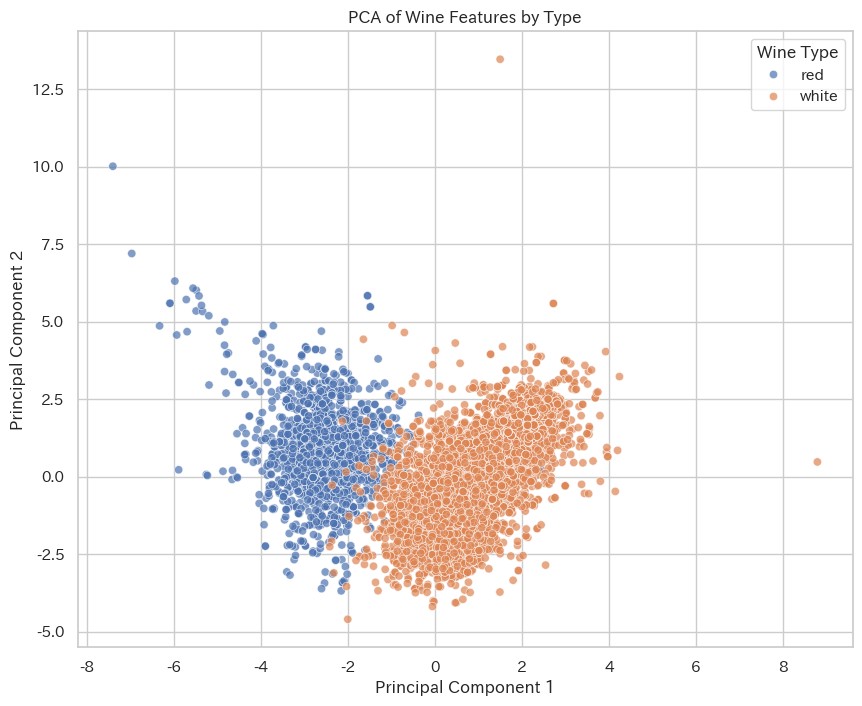

In [32]:
# ヒント：
# x=PC1, y=PC2, hue=type で散布図を作る
plt.figure(figsize=(10, 8))
sns.scatterplot(x='PC1', y='PC2', hue='type', data=pca_df, alpha=0.7)
plt.title('PCA of Wine Features by Type')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Wine Type')
plt.grid(True)
plt.show()

### 7-3. 寄与率を確認する


In [33]:
# ヒント：
# pca.explained_variance_ratio_ を確認する
print(pca.explained_variance_ratio_)


[0.2754426  0.22671146]


### 記入欄

PCAの結果から、赤ワインと白ワインの違いが見えるかを説明してください。

```text
ここに記入：
PCAの結果として得られた散布図を見ると、第一主成分（PC1）と第二主成分（PC2）の空間において、赤ワインと白ワインは明確に異なるクラスターを形成している。

```

---

## 8. 特徴量重要度

Random Forestを使って、分類に重要だった特徴量を確認してください。

### 8-1. 特徴量重要度を表にする


In [34]:
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf_model.feature_importances_
}).sort_values(by='importance', ascending=False)

print(importance_df)


                 feature  importance
6   total_sulfur_dioxide    0.303328
4              chlorides    0.265940
1       volatile_acidity    0.115063
7                density    0.067401
9              sulphates    0.057267
3         residual_sugar    0.049703
5    free_sulfur_dioxide    0.046493
0          fixed_acidity    0.043595
2            citric_acid    0.021640
8                     ph    0.020617
10               alcohol    0.008953


### 8-2. 特徴量重要度を可視化する


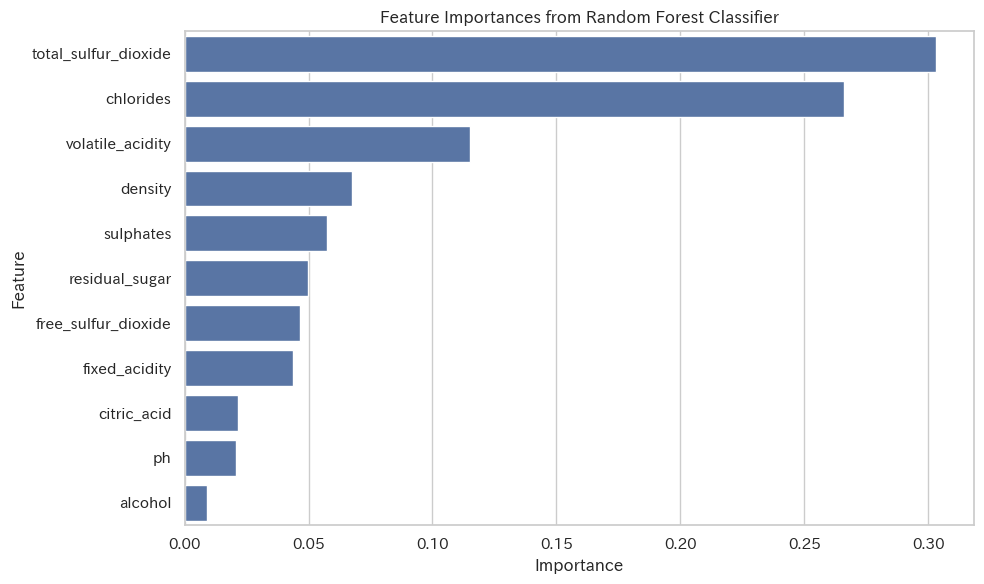

In [35]:
plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=importance_df)
plt.title('Feature Importances from Random Forest Classifier')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


### 記入欄

どの特徴量が分類に重要だったか、その結果が妥当そうかを説明してください。

```text
ここに記入：
Random Forest分類モデルの結果から、total_sulfur_dioxide（総亜硫酸）とchlorides（塩化物）がワインのタイプ（赤ワイン/白ワイン）を分類する上で最も重要な特徴量であることが示された。これらの化学的特徴は、ワインの種類を区別する上で一般的に重要な要素であり、特に白ワインは赤ワインと比較して総亜硫酸の含有量が多い傾向があるため、この結果は妥当であると考えられる。
```

---

## 9. Discussion：結果の解釈と限界

以下の観点を含めて、今回の分析をまとめてください。

- 分類はうまくいったか
- 回帰はうまくいったか
- どの特徴量が重要そうだったか
- 図から何が読み取れたか
- この分析の限界は何か
- 追加で行うとよい分析は何か

```text
ここに記入：
本分析では、Random Forestモデルがワインタイプ分類で約99.7%の高精度を達成し、品質スコア予測回帰でもいい結果（R²=0.68）がわかった。`total_sulfur_dioxide`と`chlorides`が分類に最も重要であり、PCAや散布図もワインタイプの明確な分離を可視化できた。
```

---

## 10. まとめ表

最後に、以下の表を完成させてください。

| 項目 | 自分の結果 |
| ---- | ---- |
| データの行数・列数 |6497行　13列  |
| 欠損値の有無 | なし |
| 分類で使った目的変数 | type|
| 分類で最も重視した評価指標 | Accuracy|
| 分類で採用したいモデル |Random Forest Classifier|
| 回帰で使った目的変数 |quality|
| 回帰で採用したいモデル |Random Forest Regressor|
| 最も重要そうだった特徴量 |total_sulfur_dioxide, chlorides|
| 今回の分析の限界 | PCAの寄与率が低い、品質スコアの主観性、データの限定性|

---

## 11. 採点観点

| 観点 | 配点 | 確認内容 |
| ---- | ---- | ---- |
| データ確認 | 20 | 行数、列数、欠損値、要約統計を確認している |
| 可視化 | 20 | 分布、群間比較、散布図などを作成し、解釈している |
| 分類分析 | 20 | 分類モデルを作り、複数の評価指標で説明している |
| 回帰分析 | 20 | 回帰モデルを作り、誤差指標と図で説明している |
| 考察 | 20 | 結果、限界、今後の分析を自分の言葉で書いている |

---

## 12. 提出前チェックリスト

- Notebookを上から順に実行した
- エラーが残っていない
- 図が表示されている
- 表が表示されている
- 記入欄を空欄のままにしていない
- AIを使った場合でも、出力を自分で確認した
- 結果の数値を文章で説明した
- 限界を書いた
